In [ ]:
# ==============================================================================
# CELL 1: TRAINING VÀ LƯU KẾT QUẢ RA FILE CSV
# ==============================================================================
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score
import warnings

warnings.filterwarnings('ignore')
torch.set_num_threads(8) 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Bắt đầu Training trên thiết bị: {device.type.upper()}")

# 1. HÀM TẢI DỮ LIỆU (Giữ nguyên kích thước gốc)
def load_and_preprocess_data(dataset_name):
    if dataset_name == 'sonar':
        # Bộ Sonar (60 chiều) - Phân loại Mìn và Đá
        data = fetch_openml(name='sonar', version=1, as_frame=False, parser='auto')
        X, y = data.data, LabelEncoder().fit_transform(data.target)
        
    elif dataset_name == 'fashion':
        # Bộ Fashion MNIST (784 chiều)
        data = fetch_openml(name='Fashion-MNIST', version=1, as_frame=False, parser='auto')
        # Lọc lấy nhãn '0' (Áo thun) và '1' (Quần dài)
        idx = (data.target == '0') | (data.target == '1')
        X, y = data.data[idx], data.target[idx]
        y = LabelEncoder().fit_transform(y)
        
        # MẸO QUAN TRỌNG: Cắt xuống còn 400 mẫu ngẫu nhiên để mô phỏng QML không mất cả ngày
        np.random.seed(42)
        random_indices = np.random.choice(len(X), 400, replace=False)
        X, y = X[random_indices], y[random_indices]
    
    # Chỉ chuẩn hóa, CHƯA nén PCA ở bước này
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X = scaler.fit_transform(X)
    return X, y

def create_quantum_layer(n_qubits, embedding_type, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits) 
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        if embedding_type == 'angle':
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
        elif embedding_type == 'amplitude':
            qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True, pad_with=0.)
        elif embedding_type == 'iqp':
            qml.IQPEmbedding(inputs, wires=range(n_qubits))
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return qml.expval(qml.PauliZ(0))
    return quantum_circuit

class HybridQMLModel(nn.Module):
    def __init__(self, n_qubits, embedding_type, n_layers):
        super().__init__()
        weight_shape = {"weights": (n_layers, n_qubits, 3)} 
        self.qlayer = qml.qnn.TorchLayer(create_quantum_layer(n_qubits, embedding_type, n_layers), weight_shape)
        self.fc = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        return self.sigmoid(self.fc(self.qlayer(x).unsqueeze(1)))

# 2. CẤU HÌNH THÔNG SỐ
DATASETS = ['sonar', 'fashion']
EMBEDDING_TYPES = ['angle', 'amplitude', 'iqp'] 

NUM_RUNS = 50    
EPOCHS = 100         
INITIAL_LR = 0.1     
N_LAYERS = 5         
seeds = np.random.randint(0, 10000, size=NUM_RUNS)

# 3. VÒNG LẶP TRAINING
all_results_data = [] 

for dataset_name in DATASETS:
    X_raw, y_raw = load_and_preprocess_data(dataset_name)
    
    for emb_type in EMBEDDING_TYPES:
        print(f"\nĐang chạy: {dataset_name.upper()} | Nhúng: {emb_type.upper()}")
        all_acc, all_f1, all_times = [], [], []
        final_run_test_hist = []

        for i in range(NUM_RUNS):
            X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.3, random_state=seeds[i])
            
            # --- CƠ CHẾ NÉN PCA TỰ ĐỘNG CHỐNG TRÀN RAM ---
            if emb_type in ['angle', 'iqp'] and X_train.shape[1] > 8:
                if i == 0: 
                    print(f"Dữ liệu {X_train.shape[1]} chiều quá lớn cho {emb_type.upper()}. Tự động nén PCA xuống 8 chiều!")
                pca = PCA(n_components=8, random_state=seeds[i])
                X_train = pca.fit_transform(X_train)
                X_test = pca.transform(X_test)
                
                # Chuẩn hóa lại góc xoay sau khi PCA
                scaler = MinMaxScaler(feature_range=(0, np.pi))
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)
            # ----------------------------------------------

            X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
            y_tr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
            X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
            
            # Tính toán số Qubit cần thiết
            n_q = X_tr.shape[1] if emb_type != 'amplitude' else int(np.ceil(np.log2(X_tr.shape[1])))
            
            model = HybridQMLModel(n_q, emb_type, n_layers=N_LAYERS).to(device)
            optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)
            criterion = nn.BCELoss()
            run_te_acc = []
            
            start_time = time.time() 
            for epoch in range(EPOCHS):
                model.train()
                optimizer.zero_grad()
                loss = criterion(model(X_tr), y_tr)
                loss.backward()
                optimizer.step()

                with torch.no_grad():
                    model.eval()
                    preds_te = (model(X_te).cpu() > 0.5).float().numpy()
                    run_te_acc.append(accuracy_score(y_test, preds_te))
                    
            run_time = time.time() - start_time
            print(f"   -> Xong Run {i+1}/{NUM_RUNS} | Qubits dùng: {n_q} | Time: {run_time:.2f}s | Acc: {run_te_acc[-1]:.4f}")

            all_acc.append(run_te_acc[-1])
            final_preds = (model(X_te).cpu() > 0.5).float().numpy()
            all_f1.append(f1_score(y_test, final_preds, average='weighted'))
            all_times.append(run_time)
            if i == NUM_RUNS - 1: final_run_test_hist = run_te_acc

        all_results_data.append({
            'Dataset': dataset_name.upper(),
            'Embedding': emb_type.upper(),
            'Accuracy': np.mean(all_acc),
            'F1_Score': np.mean(all_f1),
            'Time_Seconds': np.mean(all_times),
            'Convergence_History': json.dumps(final_run_test_hist) 
        })

df_export = pd.DataFrame(all_results_data)
csv_filename = 'qml_benchmark_results.csv'
df_export.to_csv(csv_filename, index=False)
print(f"\nĐÃ XUẤT THÀNH CÔNG DỮ LIỆU RA FILE: {csv_filename}")

Bắt đầu Training trên thiết bị: CUDA

Đang chạy: SONAR | Nhúng: ANGLE
Dữ liệu 60 chiều quá lớn cho ANGLE. Tự động nén PCA xuống 8 chiều!
   -> Xong Run 1/50 | Qubits dùng: 8 | Time: 21.83s | Acc: 0.8095
   -> Xong Run 2/50 | Qubits dùng: 8 | Time: 23.79s | Acc: 0.8413
   -> Xong Run 3/50 | Qubits dùng: 8 | Time: 24.07s | Acc: 0.8095
   -> Xong Run 4/50 | Qubits dùng: 8 | Time: 22.61s | Acc: 0.7460
   -> Xong Run 5/50 | Qubits dùng: 8 | Time: 23.57s | Acc: 0.7460
   -> Xong Run 6/50 | Qubits dùng: 8 | Time: 23.74s | Acc: 0.8254
   -> Xong Run 7/50 | Qubits dùng: 8 | Time: 23.03s | Acc: 0.9048
   -> Xong Run 8/50 | Qubits dùng: 8 | Time: 23.10s | Acc: 0.8254
   -> Xong Run 9/50 | Qubits dùng: 8 | Time: 23.23s | Acc: 0.8730
   -> Xong Run 10/50 | Qubits dùng: 8 | Time: 23.42s | Acc: 0.8254
   -> Xong Run 11/50 | Qubits dùng: 8 | Time: 20.28s | Acc: 0.8095
   -> Xong Run 12/50 | Qubits dùng: 8 | Time: 20.37s | Acc: 0.7778
   -> Xong Run 13/50 | Qubits dùng: 8 | Time: 21.58s | Acc: 0.8730
 

📂 Đang đọc dữ liệu từ: qml_benchmark_results.csv

🎨 Đang vẽ đồ thị cho bộ dữ liệu: SONAR


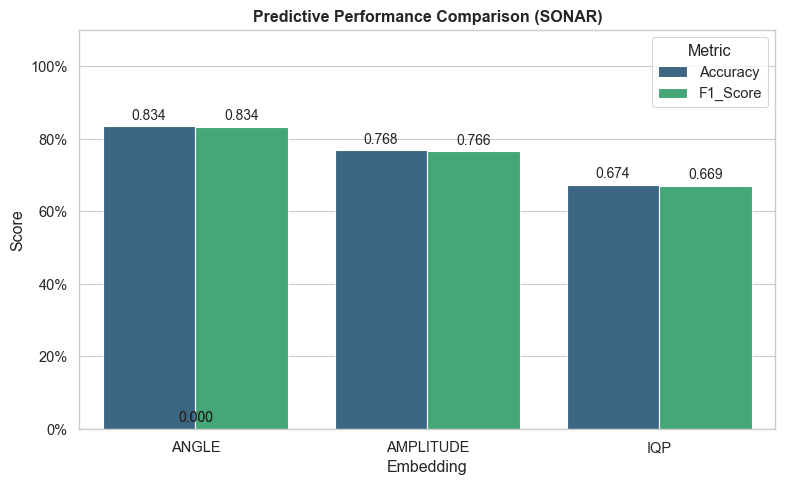

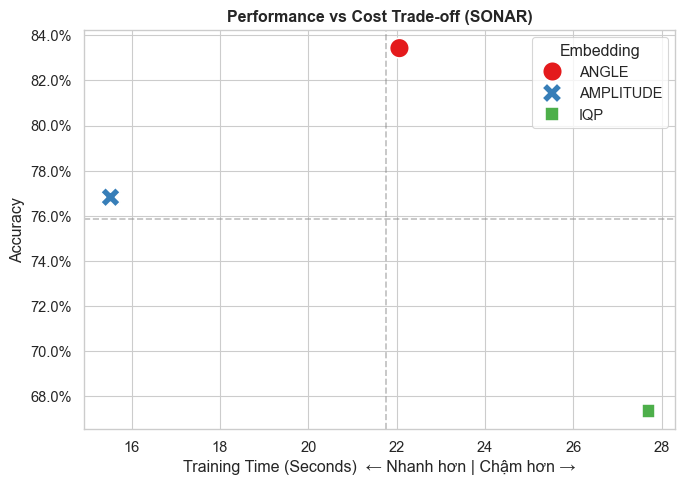

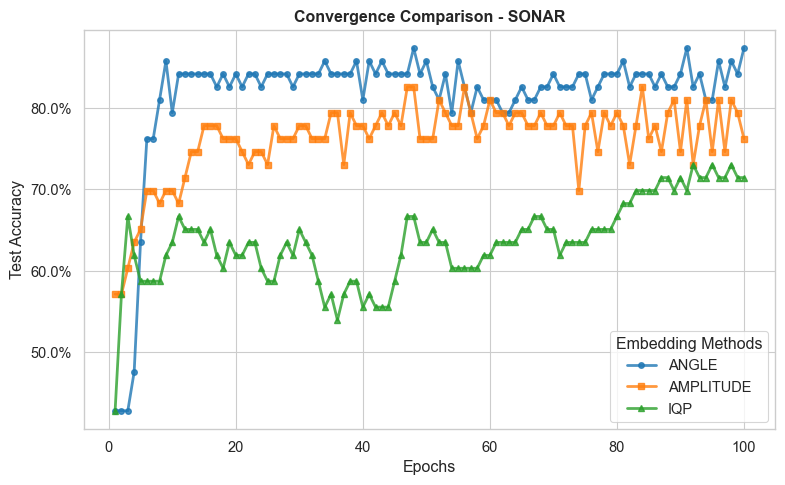


🎨 Đang vẽ đồ thị cho bộ dữ liệu: FASHION


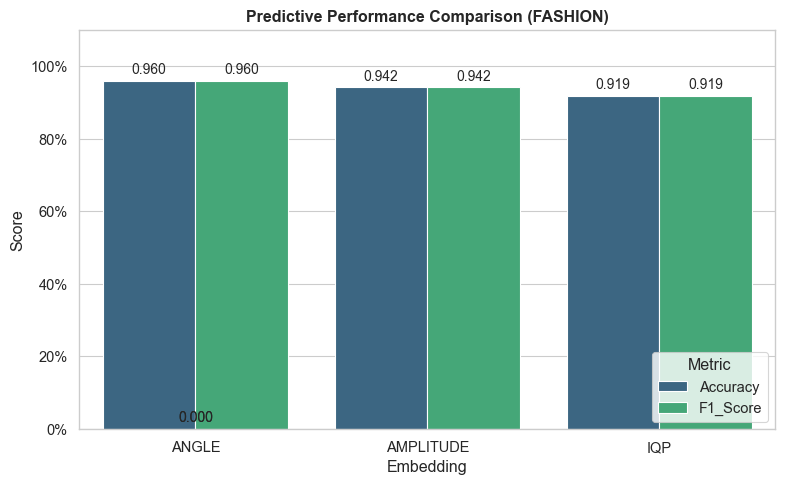

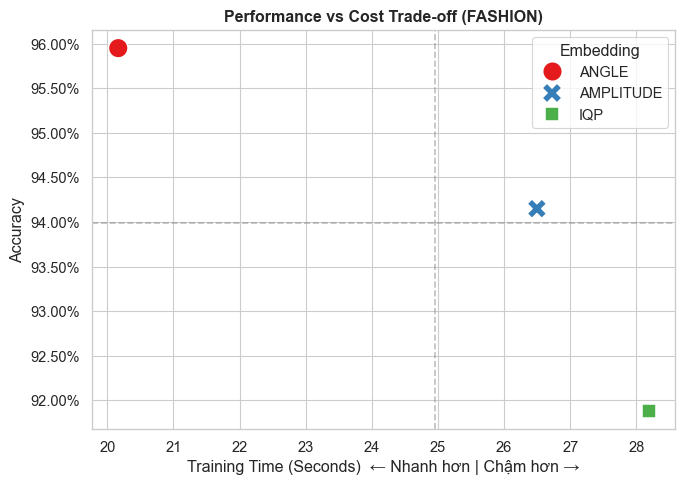

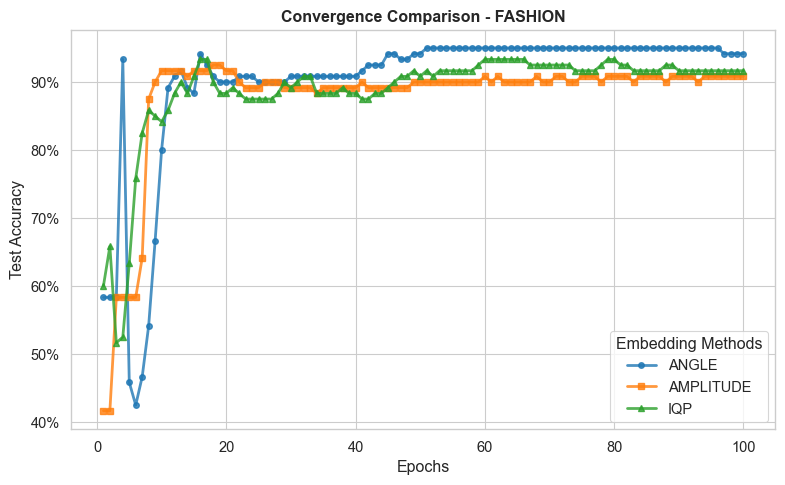


🎉 HOÀN TẤT! Tất cả các biểu đồ đã được vẽ và lưu thành công.


In [16]:
# ==============================================================================
# CELL 2: ĐỌC DỮ LIỆU TỪ CSV VÀ VẼ BIỂU ĐỒ 
# ==============================================================================
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

def plot_performance_comparison(results_df, dataset_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    df_melted = results_df.melt(id_vars='Embedding', value_vars=['Accuracy', 'F1_Score'], 
                                var_name='Metric', value_name='Score')
    sns.barplot(data=df_melted, x='Embedding', y='Score', hue='Metric', palette='viridis', ax=ax)
    ax.set_title(f'Predictive Performance Comparison ({dataset_name})', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'fig_perf_{dataset_name}.png', dpi=300)
    plt.show()

def plot_convergence_curves(history_dict, dataset_name):
    fig, ax = plt.subplots(figsize=(8, 5))
    markers, colors = ['o', 's', '^', 'D'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, (emb_name, history) in enumerate(history_dict.items()):
        ax.plot(range(1, len(history) + 1), history, label=emb_name, marker=markers[i%len(markers)], 
                markersize=4, color=colors[i%len(colors)], linewidth=2, alpha=0.8)
    ax.set_title(f'Convergence Comparison - {dataset_name}', fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Test Accuracy')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(title="Embedding Methods")
    plt.tight_layout()
    plt.savefig(f'fig_convergence_{dataset_name}.png', dpi=300)
    plt.show()

def plot_tradeoff_analysis(results_df, dataset_name):
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.scatterplot(data=results_df, x='Time_Seconds', y='Accuracy', hue='Embedding', style='Embedding', s=200, palette='Set1', ax=ax)
    ax.set_title(f'Performance vs Cost Trade-off ({dataset_name})', fontweight='bold')
    ax.set_xlabel('Training Time (Seconds)  ← Nhanh hơn | Chậm hơn →')
    ax.set_ylabel('Accuracy')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # Vẽ đường chia cắt chỉ khi có dữ liệu đủ đa dạng
    if len(results_df) > 1:
        ax.axvline(x=results_df['Time_Seconds'].mean(), color='gray', linestyle='--', alpha=0.5)
        ax.axhline(y=results_df['Accuracy'].mean(), color='gray', linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.savefig(f'fig_tradeoff_{dataset_name}.png', dpi=300)
    plt.show()

# ==========================================
# THỰC THI ĐỌC VÀ VẼ
# ==========================================
csv_filename = 'qml_benchmark_results.csv'

try:
    print(f"📂 Đang đọc dữ liệu từ: {csv_filename}")
    df_results = pd.read_csv(csv_filename)
    
    # Giải nén chuỗi JSON trong cột Convergence_History thành kiểu list chuẩn
    df_results['Convergence_History'] = df_results['Convergence_History'].apply(json.loads)
    
    # Tìm tất cả các dataset đã được lưu trong CSV
    datasets_in_csv = df_results['Dataset'].unique()
    
    for ds_name in datasets_in_csv:
        print(f"\n🎨 Đang vẽ đồ thị cho bộ dữ liệu: {ds_name}")
        # Lọc dữ liệu riêng cho từng Dataset
        df_ds = df_results[df_results['Dataset'] == ds_name]
        
        # 1. Vẽ Performance
        plot_performance_comparison(df_ds, ds_name)
        
        # 2. Vẽ Trade-off
        plot_tradeoff_analysis(df_ds, ds_name)
        
        # 3. Chuẩn bị dữ liệu và Vẽ Convergence
        # Biến 2 cột DataFrame thành dict: {'ANGLE': [0.1, 0.2...], 'IQP': [0.1, 0.3...]}
        history_dict = dict(zip(df_ds['Embedding'], df_ds['Convergence_History']))
        plot_convergence_curves(history_dict, ds_name)
        
    print("\n🎉 HOÀN TẤT! Tất cả các biểu đồ đã được vẽ và lưu thành công.")

except FileNotFoundError:
    print(f"❌ Không tìm thấy file '{csv_filename}'. Hãy chắc chắn bạn đã chạy Cell Training trước!")